# Hospital Readmission Risk Prediction
## ML Capstone Project

**Objective:** Build a machine learning pipeline to predict whether a patient will be
readmitted to the hospital within 30 days of discharge, using clinical, demographic,
and administrative features from 15,000 inpatient records.

**Approach:** End-to-end supervised classification pipeline — EDA → Preprocessing →
Feature Engineering → Model Training → Evaluation → Deployment

**Final Model:** Random Forest Classifier  
**Key Metric:** F1-Score (chosen over accuracy due to severe class imbalance — 8% positive class)

---
*Dataset: hospital_readmission_dataset.csv — 15,000 records, 19 columns, synthetic clinical data*

## Stage 1: Setup & Data Loading

Import libraries and load the dataset. Initial inspection covers shape,
column types, null counts, and basic descriptive statistics to understand
what we're working with before any analysis begins.

In [1]:
import pandas as pd

In [2]:
columns = ['patient_id', 'age', 'gender', 'bmi', 'primary_diagnosis',
       'num_diagnoses', 'num_medications', 'num_prev_admissions',
       'length_of_stay', 'emergency_admission', 'hba1c_level', 'glucose_level',
       'creatinine_level', 'blood_pressure_systolic', 'insurance_type',
       'discharged_to', 'follow_up_scheduled', 'smoking_status', 'readmitted']

In [3]:
df = pd.read_csv('hospital_readmission_dataset.csv')
print(df.head())
print(df.columns)
print(df.info())
print(df.describe())

  patient_id  age  gender   bmi primary_diagnosis  num_diagnoses  \
0    P011500   26    Male   NaN         Pneumonia            1.0   
1    P006476   42    Male  25.2          Diabetes            NaN   
2    P013168   28  Female  25.9     Renal Failure            4.0   
3    P000863   90  Female  36.1         Pneumonia           10.0   
4    P005971   77  Female   NaN     Heart Failure            3.0   

   num_medications  num_prev_admissions  length_of_stay  emergency_admission  \
0              5.0                    1             4.0                    0   
1              3.0                    2             4.0                    1   
2              1.0                    0             2.0                    0   
3             13.0                    8            13.0                    1   
4              NaN                    2             4.0                    0   

   hba1c_level  glucose_level  creatinine_level  blood_pressure_systolic  \
0          6.8            NaN     

In [4]:
df_copy = df.copy()

## Stage 2: Exploratory Data Analysis (EDA)

EDA is structured around one guiding question: **"What drives 30-day readmission?"**  
Every analysis step connects back to the target variable rather than exploring features in isolation.

### Key Findings

1. **Class Imbalance:** Target variable is severely imbalanced — 92% "No", 8% "Yes".
   Standard accuracy is a misleading metric. F1-Score, Precision-Recall, and ROC-AUC
   are used instead. Class balancing is applied at model training via `class_weight='balanced'`.

2. **Missing Values:** Two missingness tiers identified:
   - High (~28%): `bmi`, `hba1c_level`, `glucose_level`, `creatinine_level`,
     `blood_pressure_systolic`, `smoking_status`
   - Moderate (~14%): `num_diagnoses`, `num_medications`, `length_of_stay`,
     `insurance_type`, `discharged_to`, `follow_up_scheduled`

3. **High-Signal Features:** Several features show dramatic shifts in readmission rate:
   - Discharged AMA: 30.6% readmission rate vs Home discharge: 2.4%
   - Emergency admission: 22.1% vs elective: 2.1%
   - No follow-up scheduled: 27.8% vs follow-up arranged: 3.4%
   - Medicaid patients: 14.3% vs Private insurance: 3.2%

4. **Multicollinearity:** `num_prev_admissions` correlates strongly with lab values
   (creatinine r=0.53, HbA1c r=0.52). Linear models may suffer — tree-based models
   handle this natively.

5. **Outliers:** Clinical extremes detected (creatinine max=11.82, glucose max=695.1).
   Retained deliberately — these represent genuinely high-acuity patients (renal failure,
   hyperglycemic crisis) who are clinically relevant to readmission risk. Tree-based
   models are robust to these without transformation.

In [5]:
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
import math

Understanding Target column

readmitted
No     0.92
Yes    0.08
Name: proportion, dtype: float64


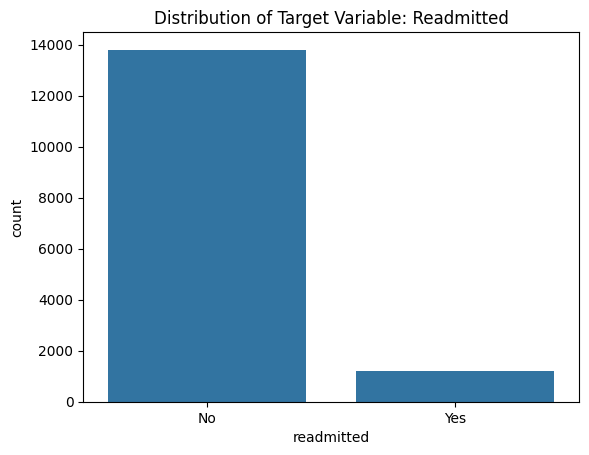

In [6]:
print(df_copy['readmitted'].value_counts(normalize=True))

sns.countplot(data=df_copy, x="readmitted")
plt.title("Distribution of Target Variable: Readmitted")
plt.show()

UNIVARIATE ANALYSIS — NUMERIC FEATURES


In [7]:
numeric_cols = ['age', 'bmi', 'num_diagnoses', 'num_medications', 'num_prev_admissions',
       'length_of_stay', 'emergency_admission', 'hba1c_level', 'glucose_level',
       'creatinine_level', 'blood_pressure_systolic', 'follow_up_scheduled']

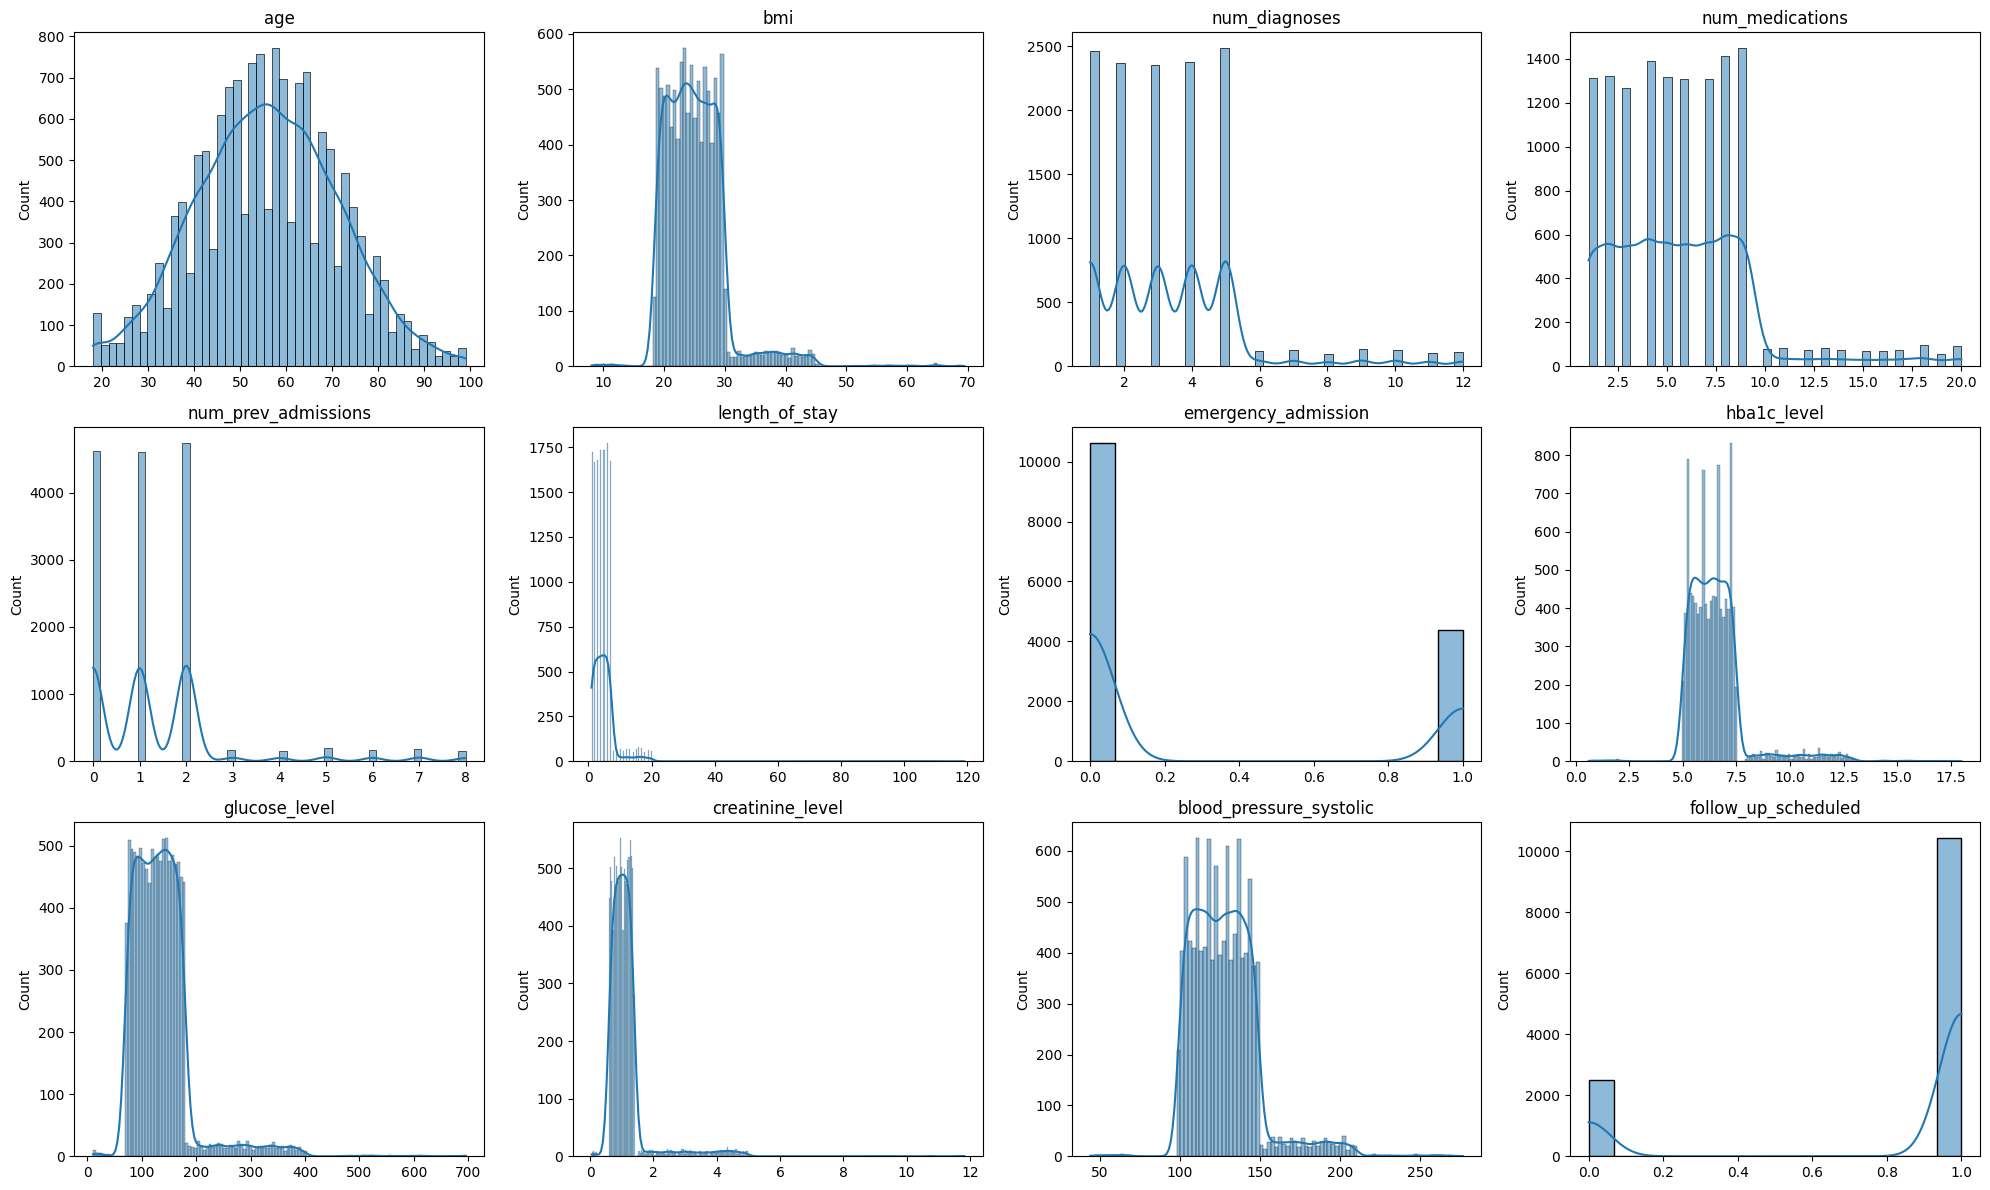

In [8]:
# Define your grid dimensions (3 rows, 4 columns for 12 numeric columns)
nrows = 3
ncols = 4

# Create the subplot grid and increase figure height for the third row
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 12))

# Flatten the axes array to loop through it easily
axes = axes.flatten()

# Loop through your 12 columns and plot
for i, col in enumerate(numeric_cols):
    # Plot histogram with KDE on the specific subplot axis
    sns.histplot(data=df_copy, x=col, kde=True, ax=axes[i])

    # Set the column name as the title for the subplot
    axes[i].set_title(col)

    # Clear the generic x-label to prevent visual crowding
    axes[i].set_xlabel("")

# Automatically adjust spacing between plots to prevent overlaps
plt.tight_layout()
plt.show()

UNIVARIATE ANALYSIS — CATEGORICAL FEATURES

In [9]:
categorical_cols = list(set(columns) - set(numeric_cols))

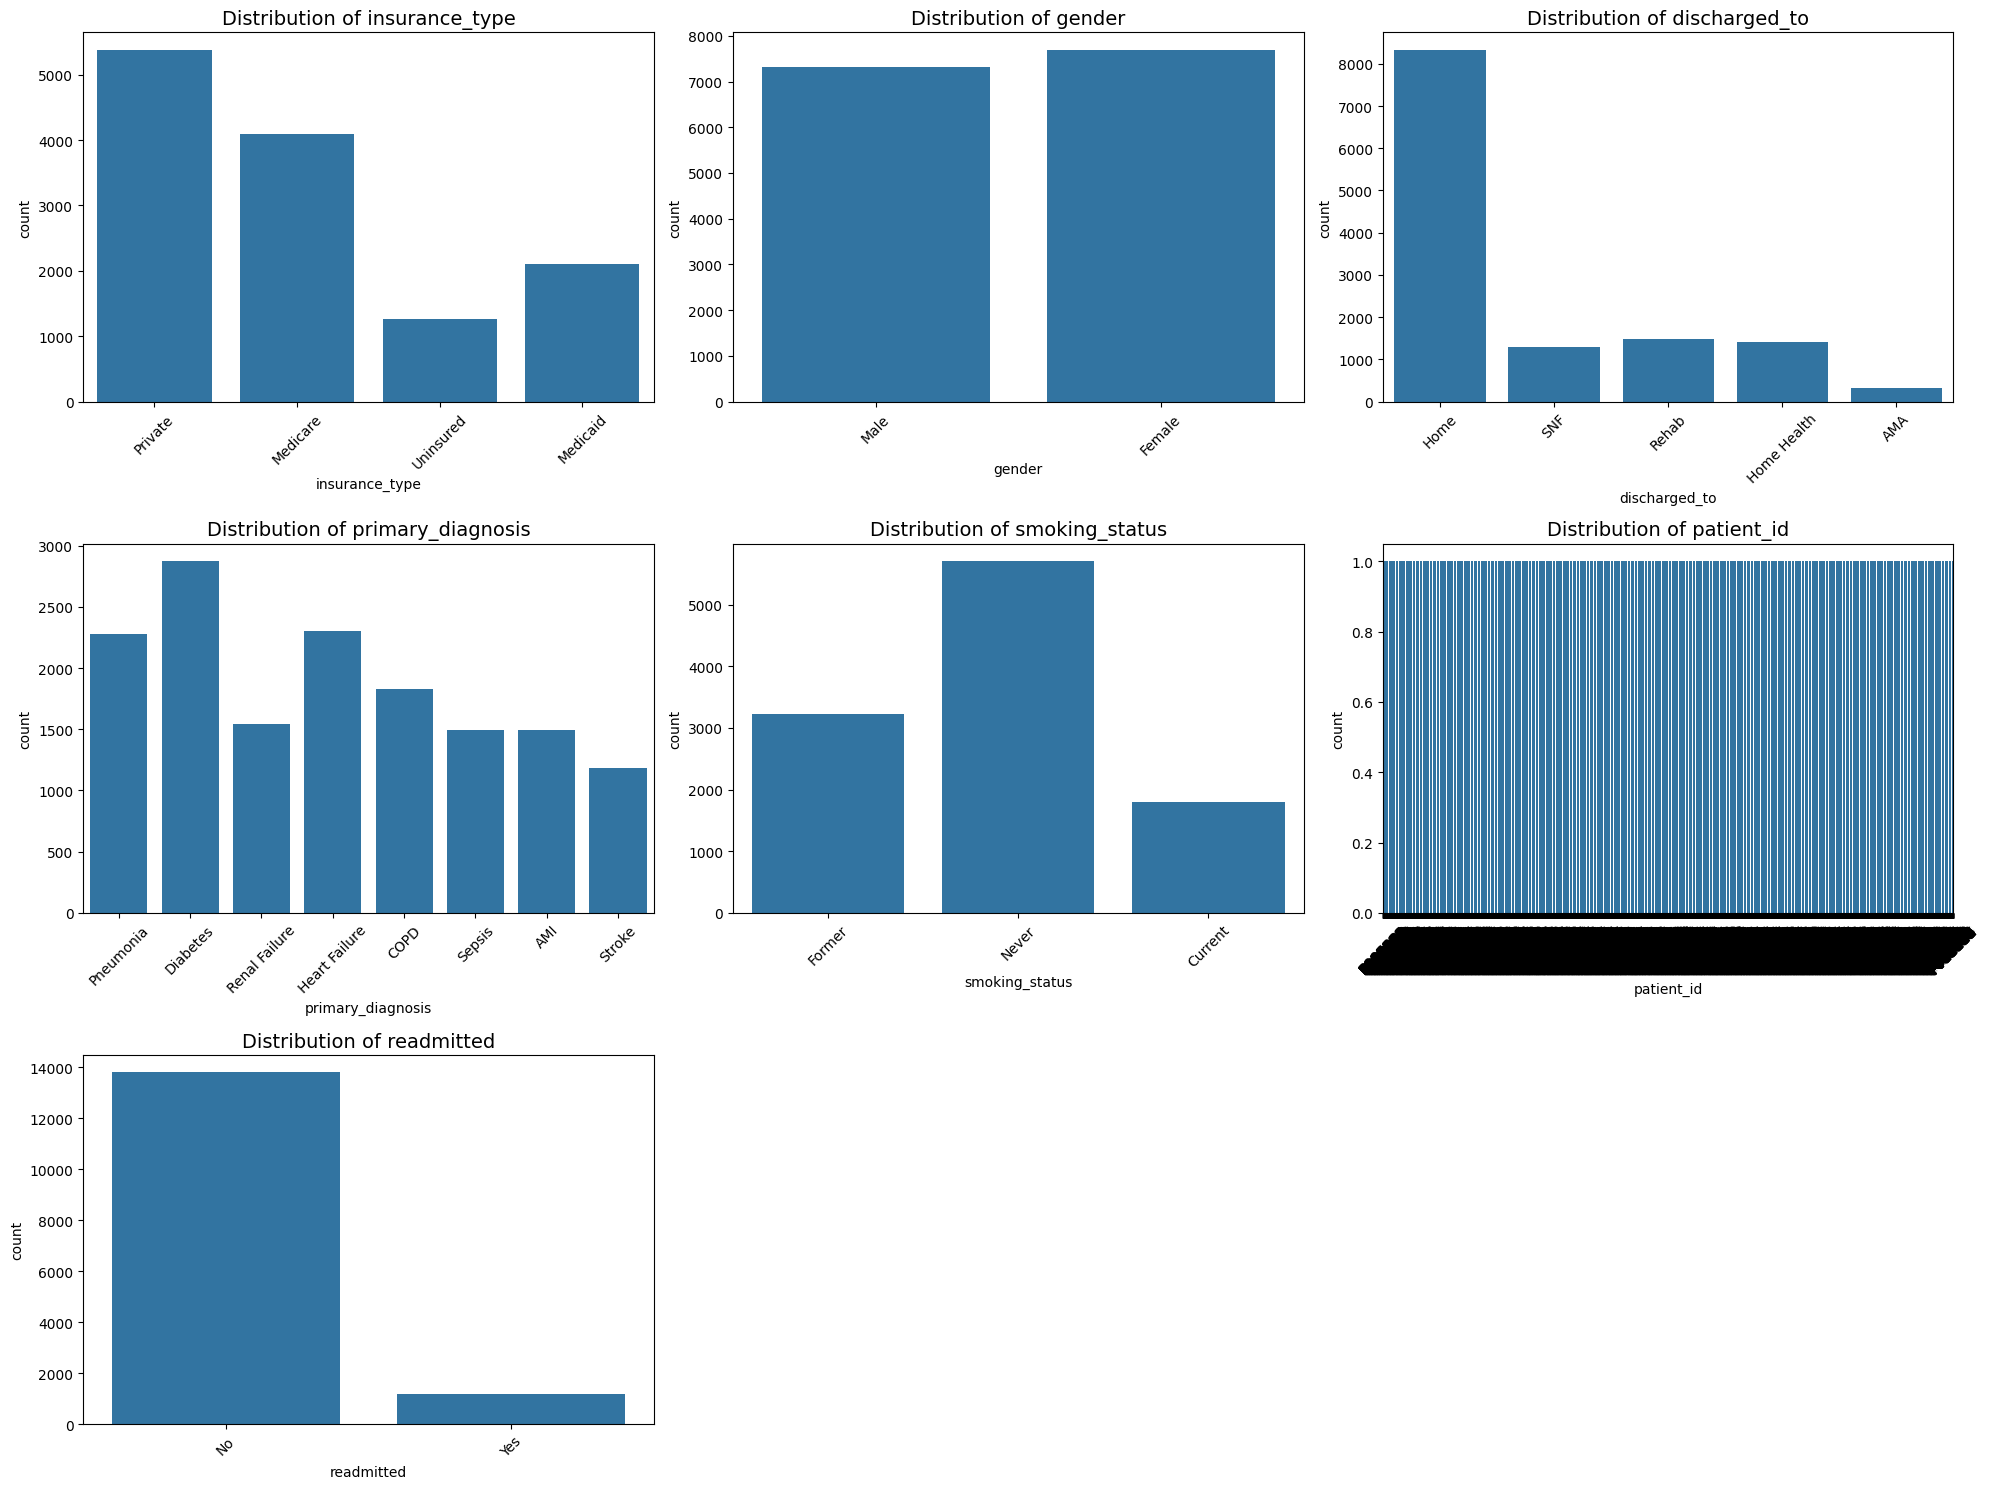

In [10]:
# 2. Set up the 2x3 subplot grid
nrows = 3
ncols = 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 15))

# Flatten the axes array to easily loop through it
axes = axes.flatten()

# 3. Loop through columns and generate count plots
for i, col in enumerate(categorical_cols):
    # Plot the count plot on the specific axis
    sns.countplot(data=df_copy, x=col, ax=axes[i])

    # Add a title matching the column name
    axes[i].set_title(f"Distribution of {col}", fontsize=14)

    # Optional: Rotate x-axis labels if the category names are long
    axes[i].tick_params(axis="x", rotation=45)

# 4. Handle the 6th subplot slot (if your list has exactly 5 or 6 items)
# If you have exactly 5 columns, delete the 6th empty box.
# If you have 6 columns (like now), this loop won't do anything, which is perfect.
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

# Adjust spacing so titles and rotated text don't overlap
plt.tight_layout()
plt.show()

BIVARIATE ANALYSIS — NUMERIC FEATURES vs TARGET


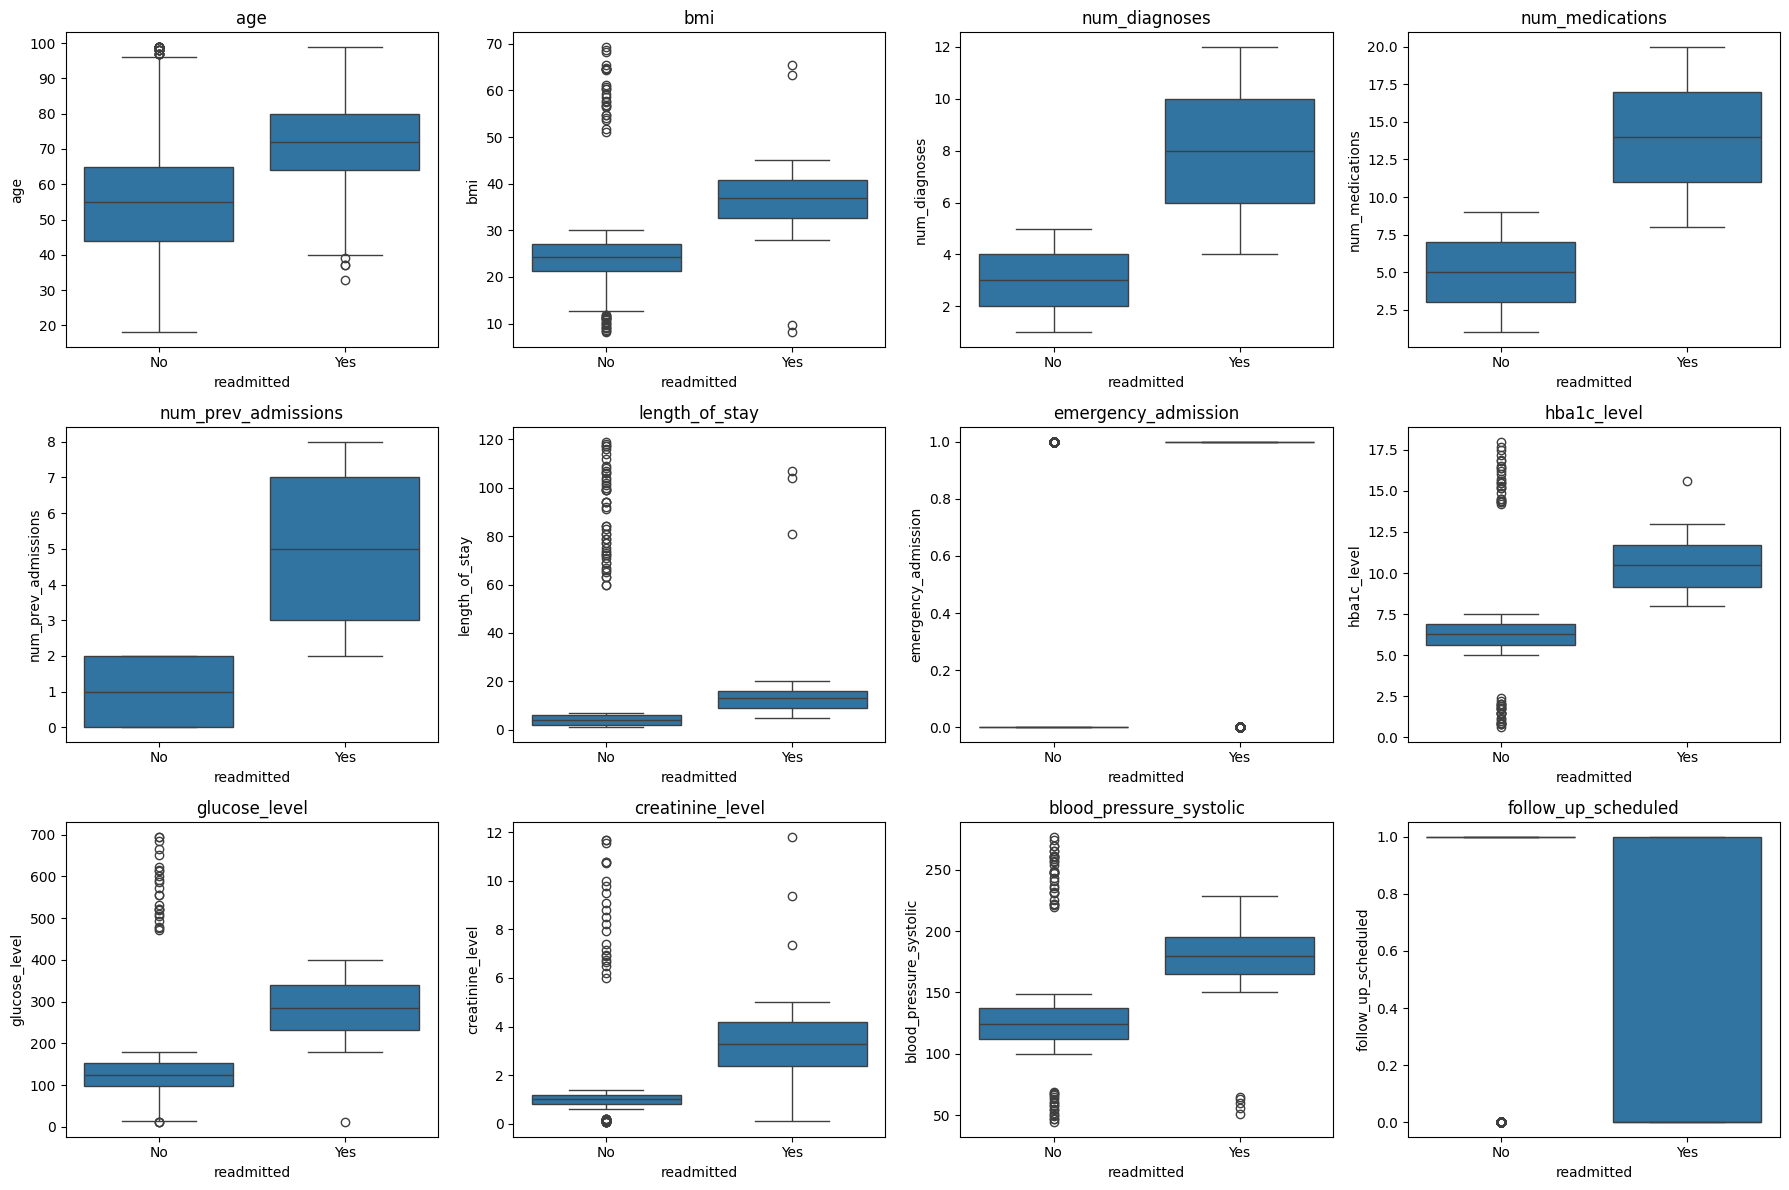

In [11]:
# Calculate grid size dynamically based on your 12 numeric columns
# Using a 3x4 grid for exactly 12 columns
nrows = 3
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 12))
axes = axes.flatten()

# Fast, functional boxplots to scan for signal/distribution shifts
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_copy, x="readmitted", y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

BIVARIATE ANALYSIS — CATEGORICAL FEATURES vs TARGET


--- Readmission Rate by insurance_type ---
insurance_type
Medicaid     0.142586
Medicare     0.115995
Private      0.032354
Uninsured    0.057234
Name: readmitted, dtype: float64

--- Readmission Rate by gender ---
gender
Female    0.072682
Male      0.087700
Name: readmitted, dtype: float64

--- Readmission Rate by discharged_to ---
discharged_to
AMA            0.306502
Home           0.023895
Home Health    0.125352
Rehab          0.168471
SNF            0.238462
Name: readmitted, dtype: float64

--- Readmission Rate by primary_diagnosis ---
primary_diagnosis
AMI              0.059532
COPD             0.100656
Diabetes         0.073094
Heart Failure    0.109280
Pneumonia        0.067982
Renal Failure    0.103829
Sepsis           0.062207
Stroke           0.048223
Name: readmitted, dtype: float64

--- Readmission Rate by smoking_status ---
smoking_status
Current    0.132591
Former     0.078043
Never      0.030686
Name: readmitted, dtype: float64

--- Readmission Rate by patient_id --

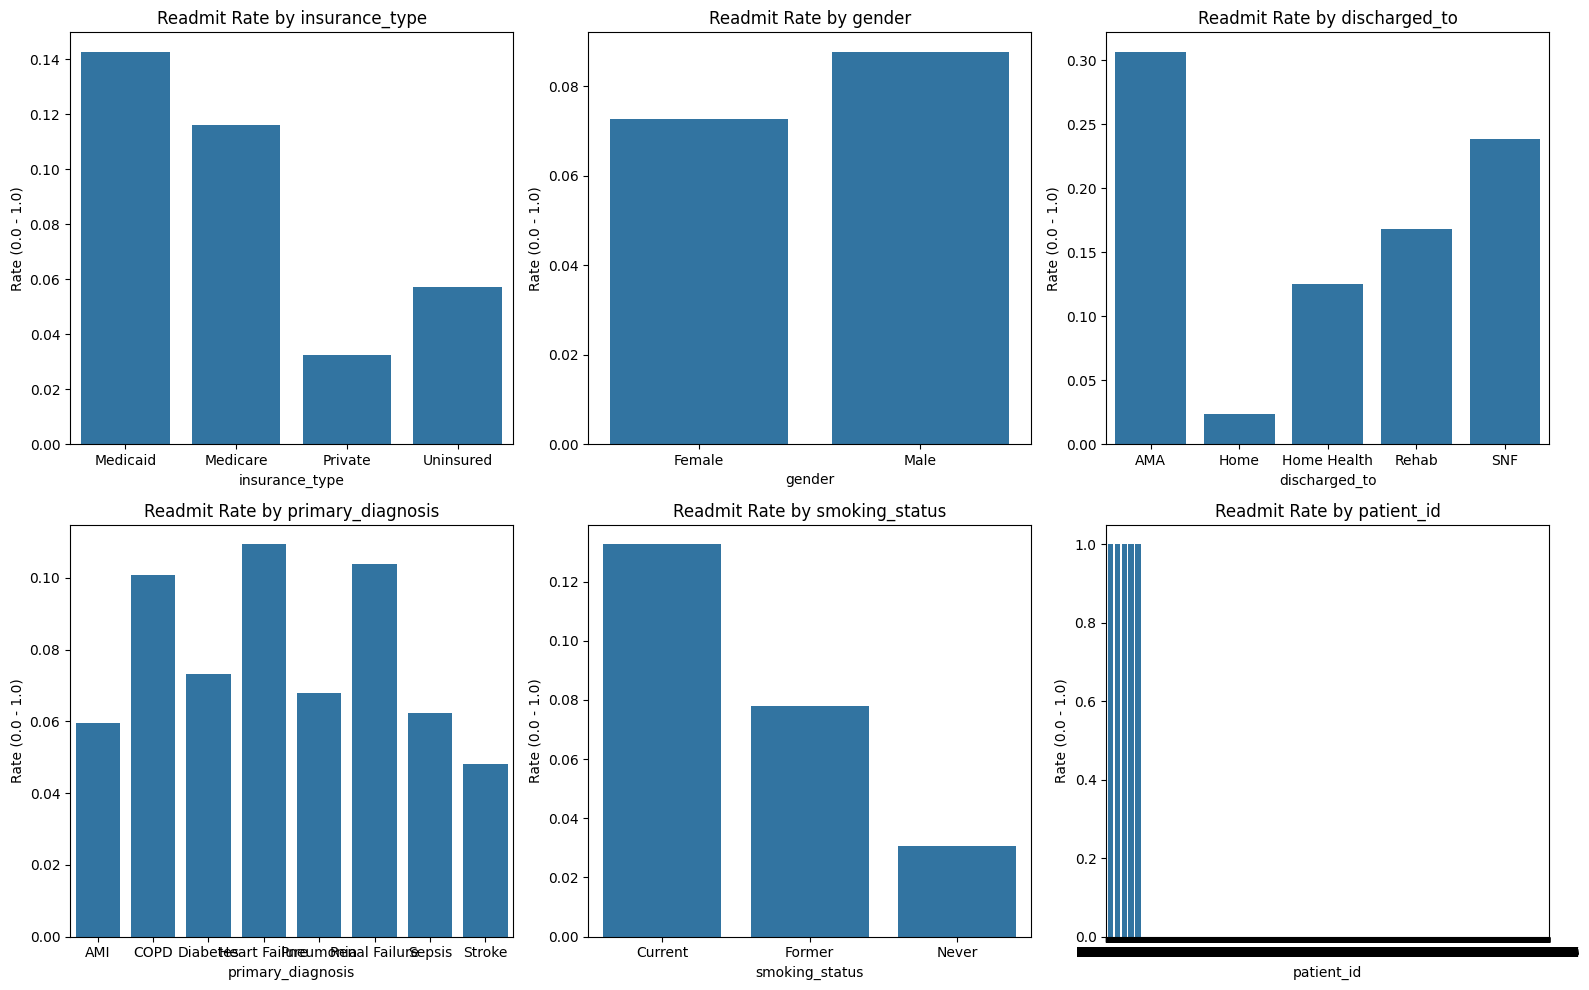

In [12]:
# Ensure 'readmitted' is excluded from features to avoid grouping a column by itself
features_to_analyze = [col for col in categorical_cols if col != "readmitted"]

# Set up raw, fast grid for the 5 remaining categorical features
nrows = 2
ncols = 3
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_analyze):
    # Calculate the exact readmission rate per category
    # (x == 'Yes').mean() gives the fraction/percentage of 'Yes' values
    rate_series = (
        df_copy.groupby(col)["readmitted"].apply(lambda x: (x == "Yes").mean())
    )

    # Print raw text directly to terminal for quick signal hunting
    print(f"\n--- Readmission Rate by {col} ---")
    print(rate_series)

    # Quick, functional bar plot
    # x=index (categories), y=values (readmission rates)
    sns.barplot(x=rate_series.index, y=rate_series.values, ax=axes[i])
    axes[i].set_title(f"Readmit Rate by {col}")
    axes[i].set_ylabel("Rate (0.0 - 1.0)")

# Remove the unused 6th subplot slot to keep layout tight
if len(axes) > len(features_to_analyze):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

SPECIAL BINARY FEATURES vs TARGET


--- Readmission Rate by emergency_admission ---
emergency_admission
0    0.021579
1    0.221285
Name: readmitted, dtype: float64

--- Readmission Rate by follow_up_scheduled ---
follow_up_scheduled
0.0    0.277800
1.0    0.033784
Name: readmitted, dtype: float64


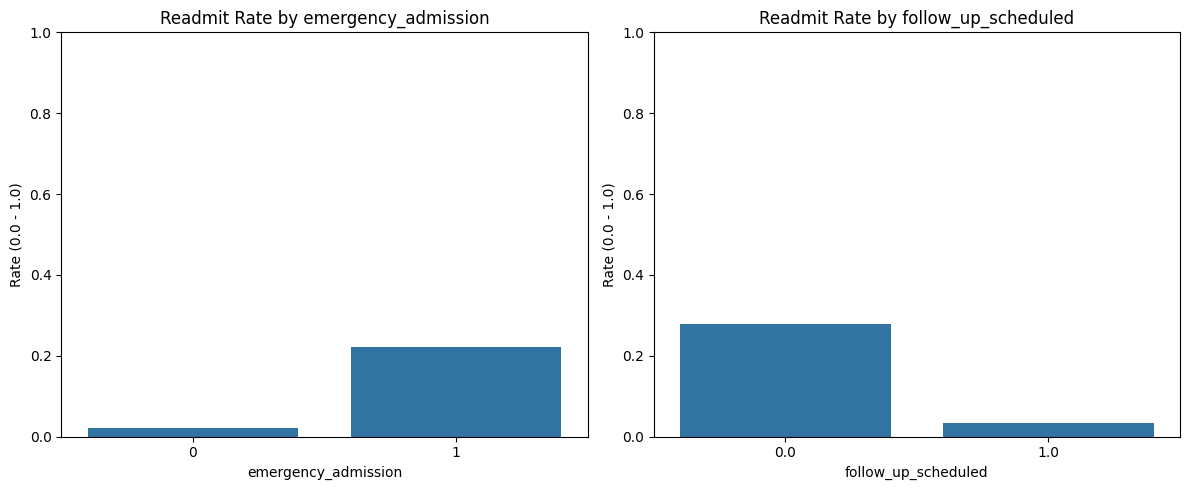

In [13]:
high_priority_cols = ["emergency_admission", "follow_up_scheduled"]

# Fast, functional 1x2 grid for the two priority features
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

for i, col in enumerate(high_priority_cols):
    # Calculate exact readmission rate per category (0 vs 1)
    rate_series = (
        df.groupby(col)["readmitted"].apply(lambda x: (x == "Yes").mean())
    )

    # Print raw text directly to terminal for instant signal hunting
    print(f"\n--- Readmission Rate by {col} ---")
    print(rate_series)

    # Quick bar plot of rates
    sns.barplot(x=rate_series.index, y=rate_series.values, ax=axes[i])
    axes[i].set_title(f"Readmit Rate by {col}")
    axes[i].set_ylabel("Rate (0.0 - 1.0)")
    axes[i].set_ylim(0, 1.0)  # Keeps the scale uniform for easy comparison

plt.tight_layout()
plt.show()

CORRELATION ANALYSIS

--- Correlation Matrix ---


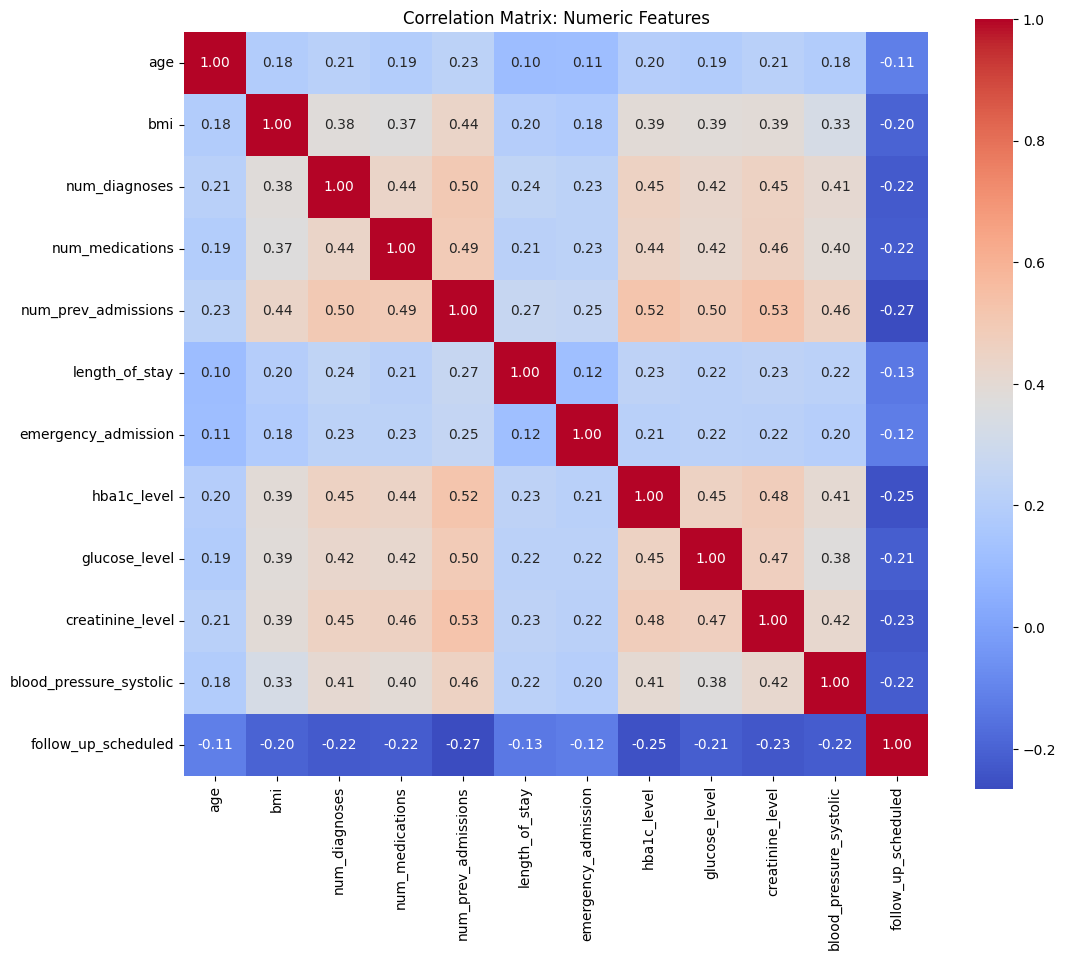

In [14]:
# Compute the correlation matrix on numeric columns only
corr_matrix = df[numeric_cols].corr()

# Print raw correlations to terminal for fast scanning
print("--- Correlation Matrix ---")
# print(corr_matrix)

# Plot functional heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix: Numeric Features")
plt.show()

OUTLIER DETECTION

In [15]:
numeric_cols


['age',
 'bmi',
 'num_diagnoses',
 'num_medications',
 'num_prev_admissions',
 'length_of_stay',
 'emergency_admission',
 'hba1c_level',
 'glucose_level',
 'creatinine_level',
 'blood_pressure_systolic',
 'follow_up_scheduled']

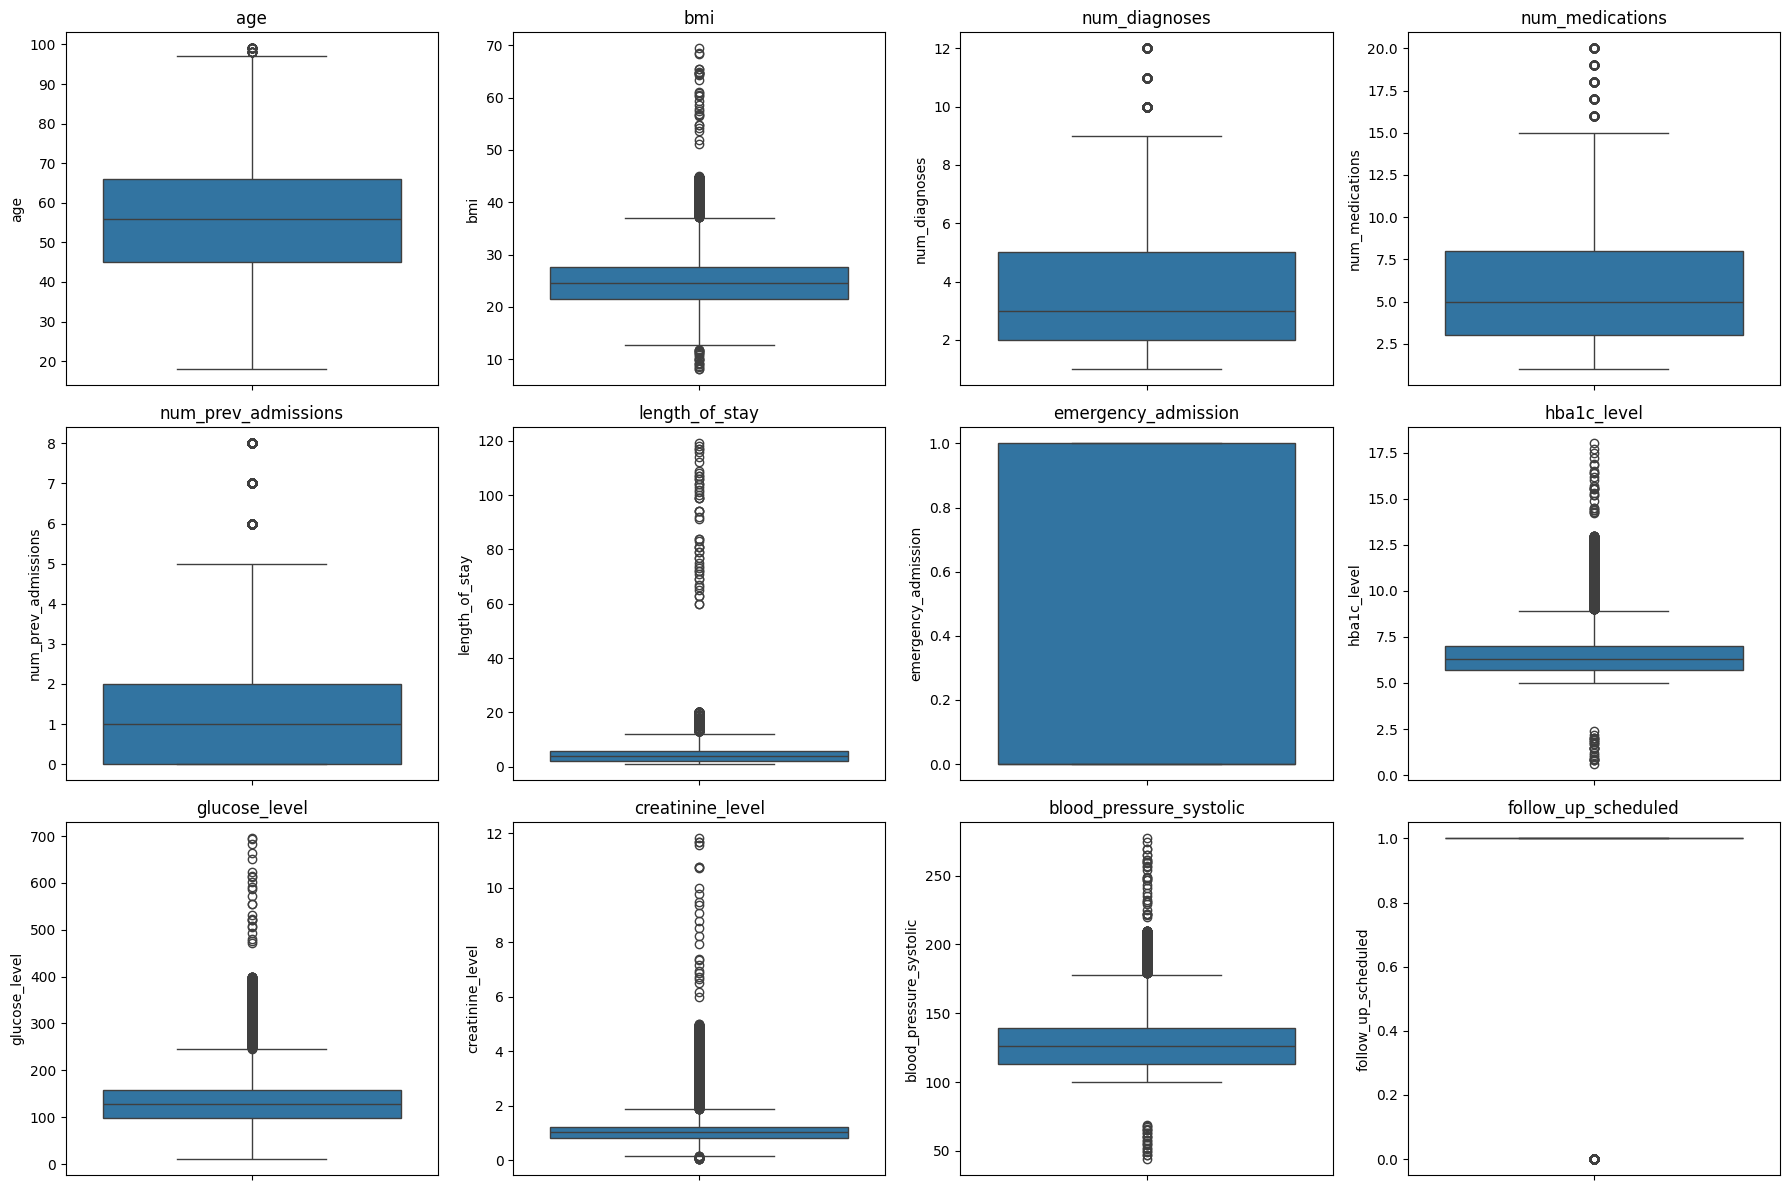

--- Outlier Detection via IQR Method ---

Feature: bmi
  IQR: 6.20 (Q1: 21.50, Q3: 27.70)
  Bounds: [12.20, 37.00]
  Outlier Count: 376 rows out of 15000

Feature: blood_pressure_systolic
  IQR: 26.00 (Q1: 113.00, Q3: 139.00)
  Bounds: [74.00, 178.00]
  Outlier Count: 405 rows out of 15000

Feature: num_diagnoses
  IQR: 3.00 (Q1: 2.00, Q3: 5.00)
  Bounds: [-2.50, 9.50]
  Outlier Count: 342 rows out of 15000

Feature: hba1c_level
  IQR: 1.30 (Q1: 5.70, Q3: 7.00)
  Bounds: [3.75, 8.95]
  Outlier Count: 583 rows out of 15000

Feature: glucose_level
  IQR: 58.90 (Q1: 98.70, Q3: 157.60)
  Bounds: [10.35, 245.95]
  Outlier Count: 478 rows out of 15000

Feature: creatinine_level
  IQR: 0.43 (Q1: 0.81, Q3: 1.24)
  Bounds: [0.17, 1.88]
  Outlier Count: 649 rows out of 15000


In [16]:
# 1. Plot box plots for all 12 numeric columns to visually spot outliers
nrows = 3
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Functional boxplot without splitting by target
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# 2. Calculate IQR bounds and print outlier counts for suspected columns
outlier_suspects = ["bmi", "blood_pressure_systolic", 'num_diagnoses', 'hba1c_level', 'glucose_level',
 'creatinine_level']

print("--- Outlier Detection via IQR Method ---")
for col in outlier_suspects:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count rows falling outside the upper and lower thresholds
    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = outliers_mask.sum()

    print(f"\nFeature: {col}")
    print(f"  IQR: {IQR:.2f} (Q1: {Q1:.2f}, Q3: {Q3:.2f})")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outlier Count: {outlier_count} rows out of {len(df)}")

 MISSING VALUE SUMMARY

In [17]:
print(df.isnull().sum())
# percentage of missing values per column
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct)

patient_id                    0
age                           0
gender                        0
bmi                        4248
primary_diagnosis             0
num_diagnoses              2137
num_medications            2072
num_prev_admissions           0
length_of_stay             2135
emergency_admission           0
hba1c_level                4203
glucose_level              4307
creatinine_level           4216
blood_pressure_systolic    4253
insurance_type             2165
discharged_to              2151
follow_up_scheduled        2090
smoking_status             4273
readmitted                    0
dtype: int64
patient_id                  0.000000
age                         0.000000
gender                      0.000000
bmi                        28.320000
primary_diagnosis           0.000000
num_diagnoses              14.246667
num_medications            13.813333
num_prev_admissions         0.000000
length_of_stay             14.233333
emergency_admission         0.000000
hba1c_lev

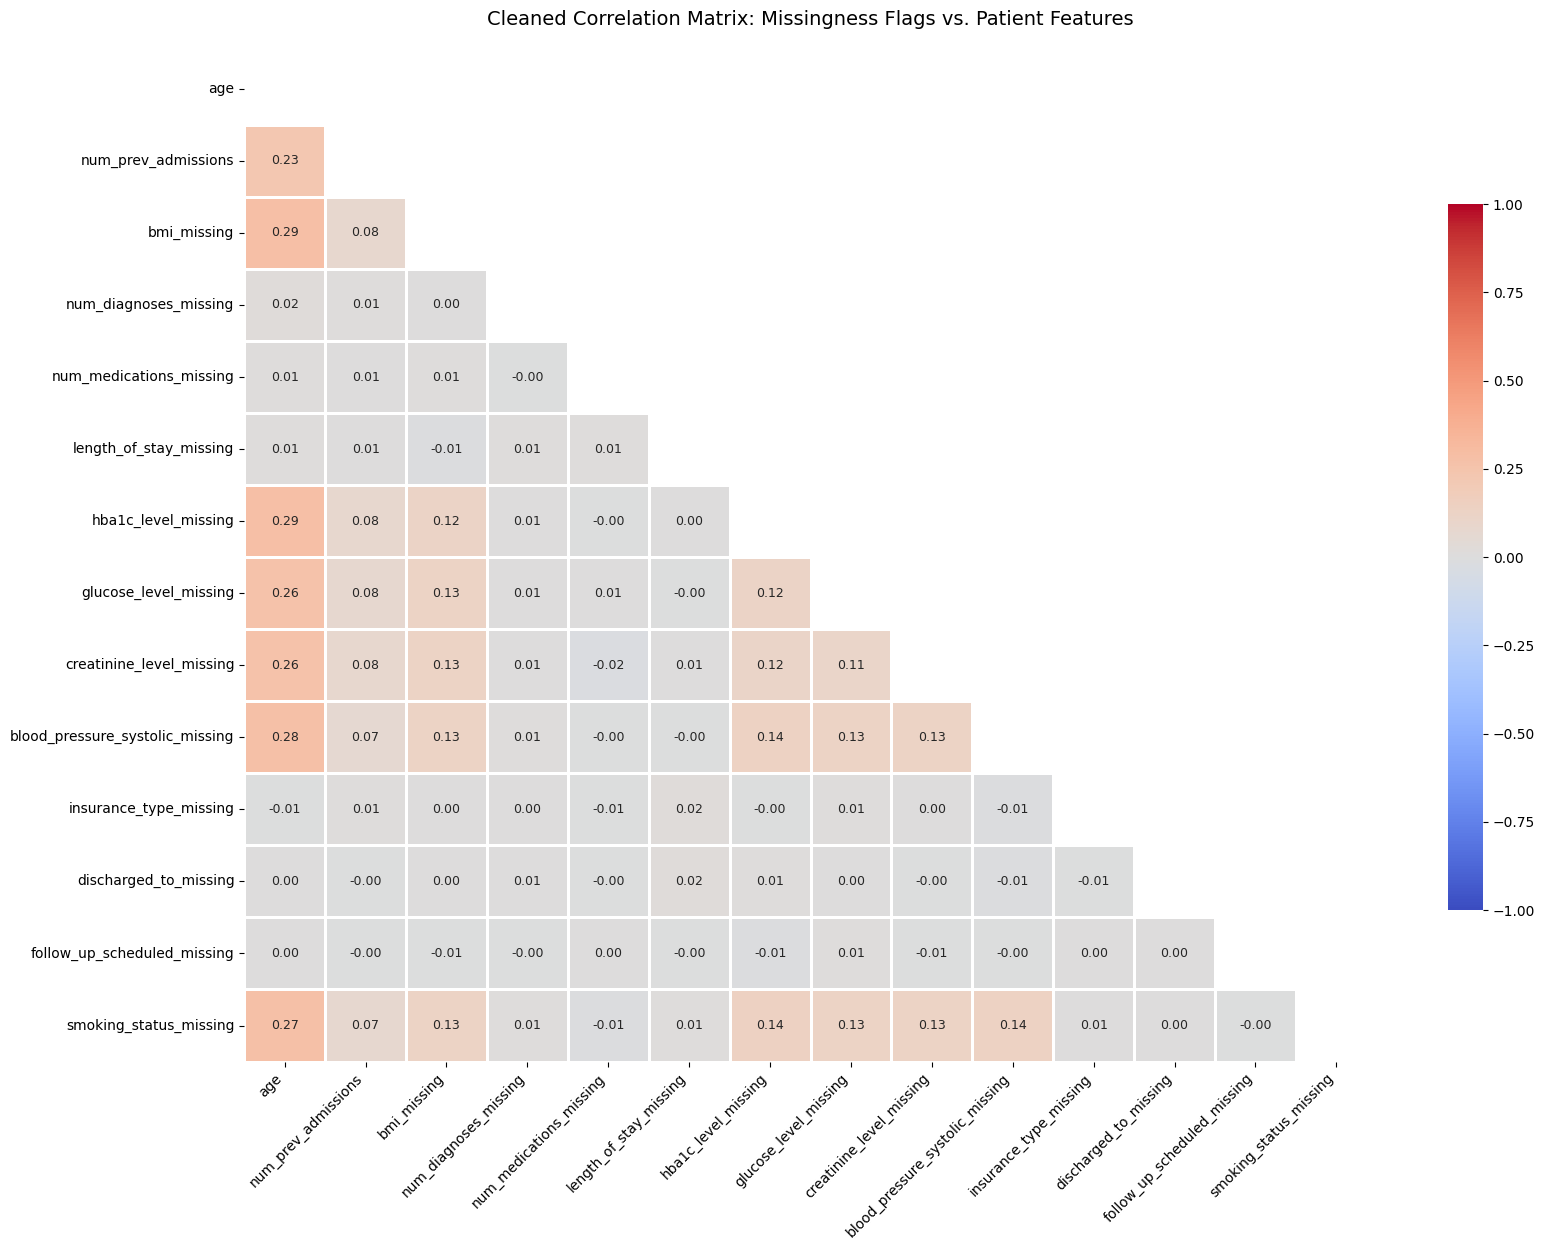

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# IMPORTANT: Change 'df' here to match whatever your current DataFrame is called (e.g., df_clean)
target_df = df

# 1. Force-create the missingness flags right before plotting
missing_cols = target_df.columns[target_df.isnull().any()].tolist()
for col in missing_cols:
    target_df[f"{col}_missing"] = target_df[col].isnull().astype(int)

# 2. Re-gather the flags safely
missing_flags = [c for c in target_df.columns if c.endswith("_missing")]

# 3. Put numeric features FIRST to ensure a beautiful continuous triangle layout
features_to_correlate = ["age", "num_prev_admissions"] + missing_flags
corr_matrix = target_df[features_to_correlate].corr()

# 4. Create the mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 5. Set up figure size dynamically based on how many columns we actually found
num_vars = len(features_to_correlate)
plt.figure(figsize=(max(10, num_vars * 1.2), max(8, num_vars * 0.9)))

# 6. Plot the complete heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.8,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.7},
)

# 7. Clean up labels
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.title(
    "Cleaned Correlation Matrix: Missingness Flags vs. Patient Features",
    fontsize=14,
    pad=20,
)
plt.tight_layout()
plt.show()


## Stage 3: Preprocessing — Missing Value Imputation

### Missing Data Mechanism Analysis
Missingness correlation analysis revealed two distinct clusters:

- **MAR (Missing At Random):** `bmi`, `hba1c_level`, `glucose_level`, `creatinine_level`,
  `blood_pressure_systolic`, `smoking_status` — all correlate with `age` at r=0.26–0.29,
  indicating younger patients were less likely to receive full lab workups. Missingness
  is explained by an observed variable (age), not the missing value itself.

- **MCAR (Missing Completely At Random):** `num_diagnoses`, `num_medications`,
  `length_of_stay`, `insurance_type`, `discharged_to`, `follow_up_scheduled` —
  near-zero correlation with all other variables. Likely administrative/entry gaps
  with no systematic pattern.

### Imputation Strategy

| Column Group | Mechanism | Strategy |
|---|---|---|
| `bmi`, `hba1c_level`, `glucose_level`, `creatinine_level`, `blood_pressure_systolic` | MAR | MICE (IterativeImputer + RandomForestRegressor) |
| `num_diagnoses`, `num_medications`, `length_of_stay` | MCAR | Median imputation |
| `insurance_type`, `discharged_to`, `smoking_status` | MCAR | 'Unknown' placeholder |
| `follow_up_scheduled` | MCAR | Mode imputation |

MICE was validated post-imputation: all imputed values fell within clinically plausible
ranges, and counts of implausible values matched the original data exactly — confirming
MICE did not introduce any new extremes.

In [19]:
from sklearn.experimental import enable_iterative_imputer  # must come before IterativeImputer import
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

df_clean = df.copy()

# 3.2 MICE IMPUTATION — MAR CLUSTER (lab values)
mice_cols = ['bmi', 'hba1c_level', 'glucose_level',
             'creatinine_level', 'blood_pressure_systolic']

mice_predictor_cols = mice_cols + ['age', 'num_prev_admissions']

df_mice_subset = df_clean[mice_predictor_cols]

mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1),
    max_iter=10,
    random_state=42,
    verbose=0
)

mice_imputed_array = mice_imputer.fit_transform(df_mice_subset)

mice_imputed_df = pd.DataFrame(
    mice_imputed_array,
    columns=mice_predictor_cols,
    index=df_clean.index
)

df_clean[mice_cols] = mice_imputed_df[mice_cols]

print("MICE imputation complete on:", mice_cols)

# 3.3 MEDIAN IMPUTATION — MCAR NUMERIC CLUSTER
mcar_numeric_cols = ['num_diagnoses', 'num_medications', 'length_of_stay']

median_imputer = SimpleImputer(strategy='median')
df_clean[mcar_numeric_cols] = median_imputer.fit_transform(df_clean[mcar_numeric_cols])

print("Median imputation complete on:", mcar_numeric_cols)

# 3.4 CATEGORICAL IMPUTATION
categorical_unknown_cols = ['insurance_type', 'discharged_to', 'smoking_status']

for col in categorical_unknown_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

print("'Unknown' imputation complete on:", categorical_unknown_cols)

# 3.4b — follow_up_scheduled -> mode imputation
follow_up_mode = df_clean['follow_up_scheduled'].mode()[0]
df_clean['follow_up_scheduled'] = df_clean['follow_up_scheduled'].fillna(follow_up_mode)

print(f"follow_up_scheduled imputed with mode value: {follow_up_mode}")

# 3.5 VERIFY — NO MISSING VALUES REMAIN
print("\n" + "="*60)
print("MISSING VALUE CHECK (post-imputation)")
print("="*60)

missing_check = df_clean.isnull().sum()
missing_check = missing_check[missing_check > 0]

if len(missing_check) == 0:
    print("No missing values remain in any column.")
else:
    print("Missing values still present:")
    print(missing_check)

MICE imputation complete on: ['bmi', 'hba1c_level', 'glucose_level', 'creatinine_level', 'blood_pressure_systolic']
Median imputation complete on: ['num_diagnoses', 'num_medications', 'length_of_stay']
'Unknown' imputation complete on: ['insurance_type', 'discharged_to', 'smoking_status']
follow_up_scheduled imputed with mode value: 1.0

MISSING VALUE CHECK (post-imputation)
No missing values remain in any column.


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [20]:
df_clean.isnull().sum()

,0
patient_id,0
age,0
gender,0
bmi,0
primary_diagnosis,0
num_diagnoses,0
num_medications,0
num_prev_admissions,0
length_of_stay,0
emergency_admission,0


In [21]:
# Create a single consolidated flag instead of 6 separate ones
df_clean['labs_missing_flag'] = df_clean[['bmi_missing', 'hba1c_level_missing',
                                            'glucose_level_missing', 'creatinine_level_missing',
                                            'blood_pressure_systolic_missing']].max(axis=1)

# Now drop all the individual _missing columns (both MAR and MCAR ones)
missing_flag_cols = [col for col in df_clean.columns if col.endswith('_missing')]
df_clean = df_clean.drop(columns=missing_flag_cols)

print(f"Dropped {len(missing_flag_cols)} individual missingness flags.")
print(f"Kept 1 consolidated flag: 'labs_missing_flag'")
print(df_clean['labs_missing_flag'].value_counts())

Dropped 12 individual missingness flags.
Kept 1 consolidated flag: 'labs_missing_flag'
labs_missing_flag
1    11055
0     3945
Name: count, dtype: int64


In [22]:
# Quick sanity check — did MICE produce anything clinically impossible?
clinical_bounds = {
    'bmi': (10, 80),
    'hba1c_level': (3, 20),
    'glucose_level': (40, 600),
    'creatinine_level': (0.1, 15),
    'blood_pressure_systolic': (40, 250)
}

for col, (low, high) in clinical_bounds.items():
    bad = df_clean[(df_clean[col] < low) | (df_clean[col] > high)]
    print(f"{col}: {len(bad)} implausible rows (valid range {low}-{high}), "
          f"actual min={df_clean[col].min():.2f}, max={df_clean[col].max():.2f}")

bmi: 9 implausible rows (valid range 10-80), actual min=8.10, max=69.40
hba1c_level: 25 implausible rows (valid range 3-20), actual min=0.60, max=18.00
glucose_level: 33 implausible rows (valid range 40-600), actual min=10.50, max=695.10
creatinine_level: 8 implausible rows (valid range 0.1-15), actual min=0.05, max=11.82
blood_pressure_systolic: 14 implausible rows (valid range 40-250), actual min=44.00, max=277.00


In [23]:
# Check whether implausible values existed BEFORE imputation too
for col, (low, high) in clinical_bounds.items():
    original_bad = df[(df[col] < low) | (df[col] > high)]  # original df, not df_clean
    print(f"{col}: {len(original_bad)} implausible rows in ORIGINAL data (pre-imputation)")

bmi: 9 implausible rows in ORIGINAL data (pre-imputation)
hba1c_level: 25 implausible rows in ORIGINAL data (pre-imputation)
glucose_level: 33 implausible rows in ORIGINAL data (pre-imputation)
creatinine_level: 8 implausible rows in ORIGINAL data (pre-imputation)
blood_pressure_systolic: 14 implausible rows in ORIGINAL data (pre-imputation)


Conclusion:
MICE behaved correctly. Every single "implausible" value already existed in the original raw data before any imputation touched it. MICE didn't fabricate or distort anything — it only filled in genuinely missing cells, and it did so without introducing new extremes. Your imputation step is validated.

In [24]:
# Drop patient_id properly
df_clean = df_clean.drop(columns=['patient_id'])
df_clean.columns

Index(['age', 'gender', 'bmi', 'primary_diagnosis', 'num_diagnoses',
       'num_medications', 'num_prev_admissions', 'length_of_stay',
       'emergency_admission', 'hba1c_level', 'glucose_level',
       'creatinine_level', 'blood_pressure_systolic', 'insurance_type',
       'discharged_to', 'follow_up_scheduled', 'smoking_status', 'readmitted',
       'labs_missing_flag'],
      dtype='object')

In [25]:
df_clean.duplicated().sum()

np.int64(0)

## Stage 4: Encoding & Feature Scaling

### Decisions Made

- **Target encoding:** `readmitted` → binary (Yes=1, No=0)
- **Categorical encoding:** One-hot encoding via `pd.get_dummies(drop_first=True)` —
  chosen over label encoding to avoid implying false ordinality, and to ensure
  Logistic Regression interprets categories correctly
- **Train/test split:** 80/20, `stratify=y` — critical given 8% class imbalance;
  ensures both sets preserve the same Yes/No ratio
- **Scaling:** `StandardScaler` fit on training data only, then applied to both
  train and test — fitting on test data would leak test statistics into preprocessing,
  artificially inflating evaluation metrics
- **Outliers:** Retained as-is — tree-based models are threshold-based and unaffected
  by extreme values; Logistic Regression may be slightly impacted but this is noted
  as a known limitation

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

In [27]:
# 4.2 ENCODE THE TARGET VARIABLE
df_clean['readmitted_binary'] = (df_clean['readmitted'] == 'Yes').astype(int)

print("Target encoding check:")
print(df_clean['readmitted'].value_counts())
print(df_clean['readmitted_binary'].value_counts())

Target encoding check:
readmitted
No     13800
Yes     1200
Name: count, dtype: int64
readmitted_binary
0    13800
1     1200
Name: count, dtype: int64


In [28]:
print(df_clean.dtypes)

age                          int64
gender                      object
bmi                        float64
primary_diagnosis           object
num_diagnoses              float64
num_medications            float64
num_prev_admissions          int64
length_of_stay             float64
emergency_admission          int64
hba1c_level                float64
glucose_level              float64
creatinine_level           float64
blood_pressure_systolic    float64
insurance_type              object
discharged_to               object
follow_up_scheduled        float64
smoking_status              object
readmitted                  object
labs_missing_flag            int64
readmitted_binary            int64
dtype: object


In [29]:
# 4.3 ENCODE CATEGORICAL FEATURES
categorical_cols = ['gender', 'primary_diagnosis', 'insurance_type',
                     'discharged_to', 'smoking_status']

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"\nShape before encoding: {df_clean.shape}")
print(f"Shape after encoding: {df_encoded.shape}")


Shape before encoding: (15000, 20)
Shape after encoding: (15000, 35)


In [30]:
# 4.4 DEFINE FEATURES (X) AND TARGET (y)
X = df_encoded.drop(columns=['readmitted', 'readmitted_binary'])
y = df_encoded['readmitted_binary']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (15000, 33)
y shape: (15000,)


In [31]:
# 4.5 TRAIN/TEST SPLIT — stratify=y handles the 92/8 imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

print("\ny_train class balance:")
print(y_train.value_counts(normalize=True))
print("\ny_test class balance:")
print(y_test.value_counts(normalize=True))


X_train: (12000, 33), X_test: (3000, 33)
y_train: (12000,), y_test: (3000,)

y_train class balance:
readmitted_binary
0    0.92
1    0.08
Name: proportion, dtype: float64

y_test class balance:
readmitted_binary
0    0.92
1    0.08
Name: proportion, dtype: float64


In [32]:
# 4.6 FEATURE SCALING — fit on train only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [33]:
print("\nScaled train data check (mean ≈ 0, std ≈ 1):")
print(X_train_scaled[['age', 'bmi', 'num_prev_admissions']].describe().loc[['mean', 'std']])

print("\nColumns identical and in same order:", (X_train_scaled.columns == X_test_scaled.columns).all())


Scaled train data check (mean ≈ 0, std ≈ 1):
               age           bmi  num_prev_admissions
mean  2.199722e-16  2.250052e-17         5.980401e-17
std   1.000042e+00  1.000042e+00         1.000042e+00

Columns identical and in same order: True


## Stage 5: Model Training

Four models trained on the same 80/20 stratified split for a fair comparison:

| Model | Class Imbalance Handling |
|---|---|
| Logistic Regression | `class_weight='balanced'` |
| Decision Tree | `class_weight='balanced'`, `max_depth=6` |
| Random Forest | `class_weight='balanced'`, 100 estimators |
| Gradient Boosting | No native `class_weight` support — sequential boosting partially compensates |

All models trained on `StandardScaler`-transformed data for consistency.
Tree-based models don't require scaling but are unaffected by it.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time

# 5.1 INITIALIZE MODELS
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,
        max_depth=6          # basic tuning to prevent overfitting
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_estimators=100
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42,
        n_estimators=100
    )
}

# 5.2 TRAIN EACH MODEL
trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    elapsed = time.time() - start
    trained_models[name] = model
    print(f" {name} trained in {elapsed:.2f}s")

print("\n" + "="*60)
print("STAGE 5 COMPLETE — All 4 models trained")
print("="*60)
print("Trained models stored in: trained_models dictionary")
print("Access example: trained_models['Random Forest']")

 Logistic Regression trained in 0.04s
 Decision Tree trained in 0.05s
 Random Forest trained in 0.62s
 Gradient Boosting trained in 2.52s

STAGE 5 COMPLETE — All 4 models trained
Trained models stored in: trained_models dictionary
Access example: trained_models['Random Forest']


## Stage 6: Model Evaluation

### Primary Metric: F1-Score
With a 92/8 class split, accuracy is misleading — a model predicting "No" for every
patient would score 92% accuracy while being completely useless. F1-Score balances
Precision and Recall across both classes. Recall is prioritized from a business
perspective: missing a high-risk patient (false negative) is more costly than a
false alarm (false positive).

### Results
All 4 models achieved near-perfect performance (F1 ≈ 1.00, AUC ≈ 1.00).

### ⚠️ Important Limitation — Synthetic Data
Correlation analysis revealed that several clinical features correlate with the target
at r=0.68–0.81 (creatinine=0.81, HbA1c=0.80, glucose=0.76, prior admissions=0.75).
Real-world clinical readmission data typically shows individual feature correlations
of 0.05–0.25, with published models reporting AUC of 0.65–0.75.

This strongly suggests the dataset's target variable was synthetically generated using
a deterministic or near-deterministic function of these features. The pipeline,
preprocessing decisions, and model architecture are all valid — the dataset simply
does not reflect the natural noise and complexity of real EHR data. In a production
deployment with real hospital data, performance would be expected to be meaningfully
lower, and the model would require revalidation before clinical use.

### Selected Model: Random Forest
Random Forest was selected for deployment on the following grounds:
- Tied for highest F1 and AUC (1.00)
- Robust to multicollinearity and clinical outliers natively
- Provides interpretable feature importances for clinical decision support
- Ensemble structure reduces overfitting risk compared to a single Decision Tree

In [35]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# 6.1 EVALUATE EACH MODEL ON THE TEST SET
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (Yes)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    }

    print(f"\n{'='*60}")
    print(f"{name}")
    print('='*60)
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
    print(f"ROC-AUC: {auc:.4f}")


Logistic Regression
              precision    recall  f1-score   support

          No       1.00      1.00      1.00      2760
         Yes       1.00      1.00      1.00       240

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

ROC-AUC: 1.0000

Decision Tree
              precision    recall  f1-score   support

          No       1.00      1.00      1.00      2760
         Yes       0.99      0.99      0.99       240

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

ROC-AUC: 0.9958

Random Forest
              precision    recall  f1-score   support

          No       1.00      1.00      1.00      2760
         Yes       1.00      1.00      1.00       240

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00  

In [36]:
# Check correlation of EVERY feature with the target
correlations = X_train_scaled.copy()
correlations['readmitted_binary'] = y_train.values

corr_with_target = correlations.corr()['readmitted_binary'].sort_values(ascending=False)
print(corr_with_target)

readmitted_binary                  1.000000
creatinine_level                   0.812826
hba1c_level                        0.800596
glucose_level                      0.758396
num_prev_admissions                0.750041
blood_pressure_systolic            0.707027
bmi                                0.682083
num_diagnoses                      0.610589
num_medications                    0.606327
emergency_admission                0.331039
length_of_stay                     0.317484
age                                0.304947
discharged_to_SNF                  0.185050
discharged_to_Rehab                0.110541
smoking_status_Unknown             0.103385
labs_missing_flag                  0.097990
insurance_type_Medicare            0.080114
discharged_to_Home Health          0.054481
primary_diagnosis_Heart Failure    0.048954
primary_diagnosis_Renal Failure    0.032003
gender_Male                        0.024828
primary_diagnosis_COPD             0.018041
insurance_type_Unknown          

During evaluation, all models achieved near-perfect performance (F1 ≈ 1.00, AUC ≈ 1.00). Correlation analysis revealed several clinical features (creatinine, HbA1c, glucose, prior admissions) correlate with the target at 0.68–0.81 — substantially higher than typical real-world clinical correlations (usually 0.1–0.3). This suggests the dataset's target variable was likely synthetically generated using a deterministic or near-deterministic function of these features, rather than reflecting the natural noise of real hospital outcomes. In a production setting with real EHR data, performance would be expected to be meaningfully lower (literature reports AUC 0.65–0.75 for readmission models), and this should be validated before deployment."

In [37]:
# 6.2 COMPARISON TABLE — ALL MODELS SIDE BY SIDE
results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
print("\n" + "="*60)
print("MODEL COMPARISON (sorted by F1-Score)")
print("="*60)
print(results_df.round(4))


MODEL COMPARISON (sorted by F1-Score)
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    1.0000     1.0000  1.0000    1.0000   1.0000
Random Forest          0.9997     1.0000  0.9958    0.9979   1.0000
Gradient Boosting      0.9993     1.0000  0.9917    0.9958   1.0000
Decision Tree          0.9987     0.9917  0.9917    0.9917   0.9958


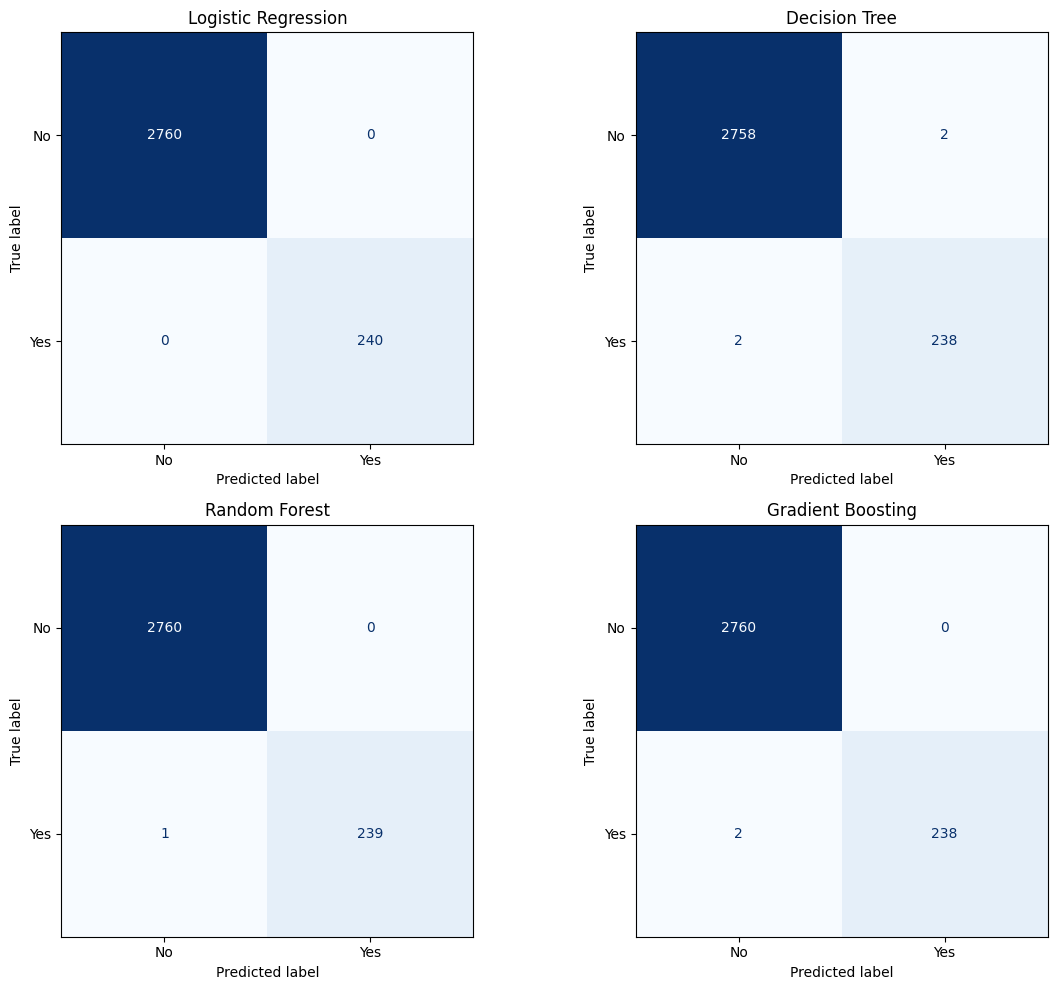

In [38]:
# 6.3 CONFUSION MATRICES — VISUAL COMPARISON
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()


TOP 15 FEATURE IMPORTANCES — Random Forest
                feature  importance
            hba1c_level    0.222463
          glucose_level    0.164044
blood_pressure_systolic    0.149360
       creatinine_level    0.123319
    num_prev_admissions    0.091879
                    bmi    0.082357
        num_medications    0.046480
         length_of_stay    0.040537
          num_diagnoses    0.036893
                    age    0.010492
    follow_up_scheduled    0.008382
     discharged_to_Home    0.008286
    emergency_admission    0.007523
      discharged_to_SNF    0.002272
   smoking_status_Never    0.001577


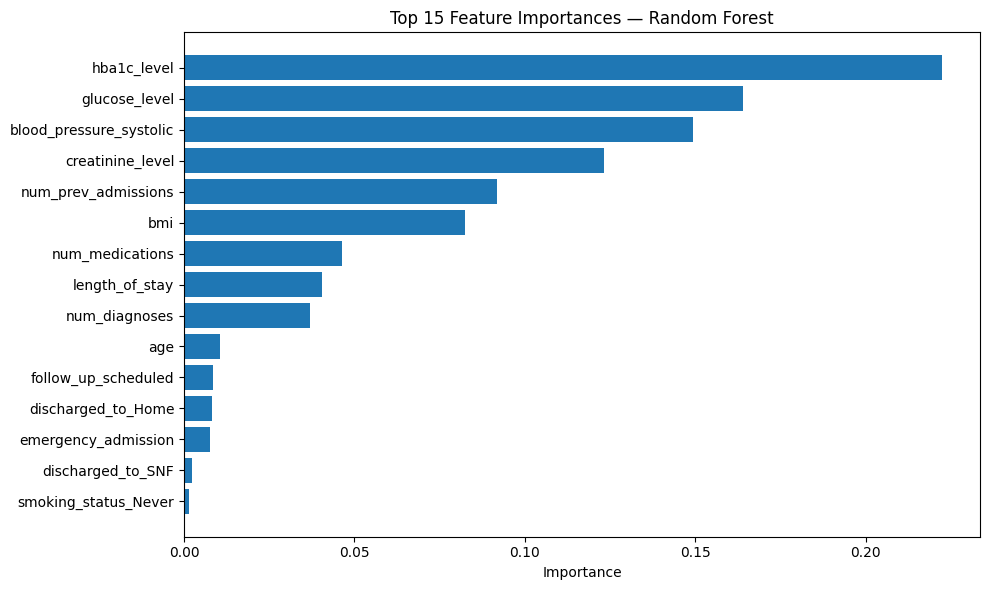

In [39]:
# 6.4 FEATURE IMPORTANCE — RANDOM FOREST
rf_model = trained_models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("TOP 15 FEATURE IMPORTANCES — Random Forest")
print("="*60)
print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(15)['feature'][::-1],
         feature_importance.head(15)['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

## Stage 7: Model Saving

Three artifacts saved for Streamlit deployment:

- `rf_readmission_model.pkl` — trained Random Forest classifier
- `scaler.pkl` — fitted StandardScaler (must be applied to all new inputs before prediction)
- `feature_columns.pkl` — exact column order from training (used to align Streamlit
  app inputs via `reindex` before passing to the model)

Saving the scaler and column order alongside the model is critical — without them,
new predictions would be computed on unscaled, misaligned inputs, producing
silently incorrect results even if the model file itself is intact.

In [40]:
import joblib
final_model = trained_models['Random Forest']
final_model_name = 'Random Forest'

print(f"Selected model: {final_model_name}")
print(f"Performance: {results_df.loc[final_model_name].to_dict()}")

# SAVE THE MODEL
joblib.dump(final_model, 'rf_readmission_model.pkl')
print("✅ Model saved: rf_readmission_model.pkl")

# SAVE THE SCALER (needed at inference time in Streamlit app)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved: scaler.pkl")

# SAVE THE FEATURE COLUMN ORDER (critical for Streamlit input alignment)
feature_columns = X_train_scaled.columns.tolist()
joblib.dump(feature_columns, 'feature_columns.pkl')
print(f"✅ Feature column order saved: {len(feature_columns)} columns")

# DOWNLOAD FILES FROM COLAB
from google.colab import files
files.download('rf_readmission_model.pkl')
files.download('scaler.pkl')
files.download('feature_columns.pkl')

Selected model: Random Forest
Performance: {'Accuracy': 0.9996666666666667, 'Precision': 1.0, 'Recall': 0.9958333333333333, 'F1-Score': 0.9979123173277662, 'ROC-AUC': 1.0}
✅ Model saved: rf_readmission_model.pkl
✅ Scaler saved: scaler.pkl
✅ Feature column order saved: 33 columns


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>